In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\ml_ids\supreme_49_attacks\all_attack_and_benign.csv")


label
BENIGN                        300332
PortScan                       20525
DDoS                           12582
DDoS-UDP_Fragmentation          5000
DDoS-UDP_Flood                  5000
DDoS-ACK_Fragmentation          5000
DDoS-RSTFINFlood                5000
DDoS-SlowLoris                  5000
DDoS-PSHACK_Flood               5000
DDoS-ICMP_Fragmentation         5000
DNS_Spoofing                    5000
DoS GoldenEye                   5000
DDoS-TCP_Flood                  5000
DDoS-SYN_Flood                  5000
DrDoS_DNS                       5000
DoS Hulk                        5000
DDoS-SynonymousIP_Flood         5000
DDoS-ICMP_Flood                 5000
TFTP                            5000
MITM-ArpSpoofing                5000
Recon-PortScan                  5000
Recon-HostDiscovery             5000
DrDoS_NetBIOS                   5000
DrDoS_NTP                       5000
DrDoS_MSSQL                     5000
DrDoS_LDAP                      5000
Fuzzers                         

C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:82: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


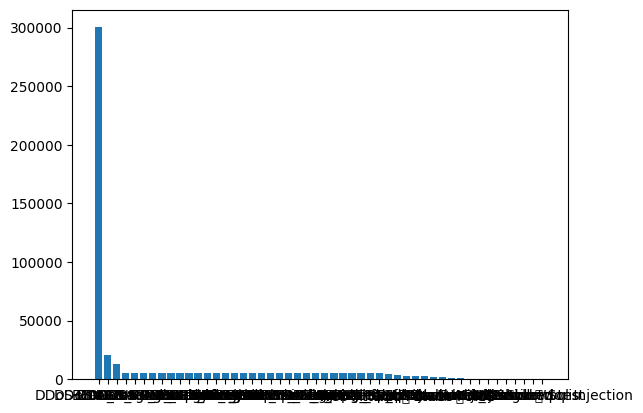

In [2]:
#visaulize
import pandas as pd
import matplotlib.pyplot as plt
data=df['label']
counts = data.value_counts()
plt.bar(counts.index, counts.values)
print(counts)

In [3]:
#dropnas
df.dropna()
print(df)
#remove space because dumb dumbs
df.columns = df.columns.str.strip()
columns = df.columns
print(columns)

        bidirectional_duration_ms  bidirectional_packets  bidirectional_bytes  \
0                            40.0                   10.0                979.0   
1                          3158.0                    4.0               1656.0   
2                            63.0                   10.0               1066.0   
3                          2138.0                    3.0               1242.0   
4                            99.0                   10.0               1063.0   
...                           ...                    ...                  ...   
501415                       59.0                    4.0                400.0   
501416                       29.0                    2.0                132.0   
501417                       23.0                    2.0                132.0   
501418                       83.0                    2.0                132.0   
501419                       39.0                    2.0                126.0   

        src2dst_duration_ms

In [4]:
df['label'] = (
    df['label']
    .str.replace('\x96', '-', regex=False)   # fix weird dash
    .str.replace('Web Attack - ', 'web_attack', regex=False)
    .str.replace("'", '', regex=False)        # remove stray quotes
    .str.strip()
)

print(df['label'].unique())

['Backdoor_Malware' 'Bot' 'BrowserHijacking' 'CommandInjection'
 'DDoS-ACK_Fragmentation' 'DDoS-ICMP_Flood' 'DDoS-ICMP_Fragmentation'
 'DDoS-PSHACK_Flood' 'DDoS-RSTFINFlood' 'DDoS-SlowLoris'
 'DDoS-SynonymousIP_Flood' 'DDoS-SYN_Flood' 'DDoS-TCP_Flood'
 'DDoS-UDP_Flood' 'DDoS-UDP_Fragmentation' 'DDoS' 'DNS_Spoofing'
 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest' 'DoS slowloris' 'DrDoS_DNS'
 'DrDoS_LDAP' 'DrDoS_MSSQL' 'DrDoS_NetBIOS' 'DrDoS_NTP' 'DrDoS_SNMP'
 'Exploits' 'FTP-Patator' 'Fuzzers' 'Generic' 'Heartbleed' 'Infiltration'
 'Mirai-greeth_flood' 'Mirai-greip_flood' 'Mirai-udpplain'
 'MITM-ArpSpoofing' 'PortScan' 'Recon-HostDiscovery' 'Recon-PortScan'
 'Shellcode' 'SqlInjection' 'SSH-Patator' 'TFTP' 'web_attackBrute Force'
 'web_attackSql Injection' 'web_attackXSS' 'Worms' 'XSS' 'BENIGN']


In [5]:
attack_columns = [
   "DrDoS_DNS", "DrDoS_LDAP", "DrDoS_MSSQL", 
        "DrDoS_NetBIOS", "DrDoS_NTP", "DrDoS_SNMP"
]
df = df[df['label'].isin(['BENIGN', *attack_columns])]

In [6]:
print(df["label"].unique())

['DrDoS_DNS' 'DrDoS_LDAP' 'DrDoS_MSSQL' 'DrDoS_NetBIOS' 'DrDoS_NTP'
 'DrDoS_SNMP' 'BENIGN']


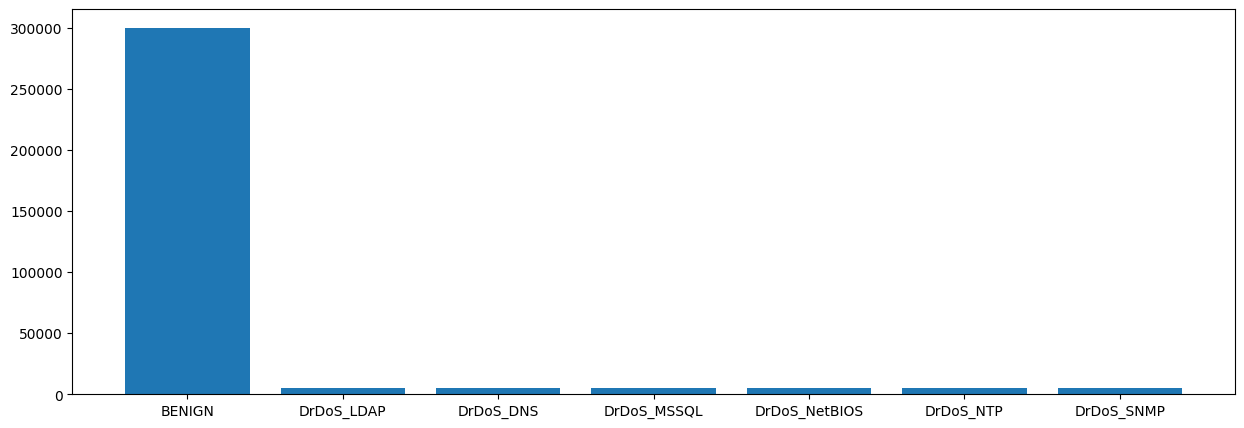

label
BENIGN           300332
DrDoS_LDAP         5000
DrDoS_DNS          5000
DrDoS_MSSQL        5000
DrDoS_NetBIOS      5000
DrDoS_NTP          5000
DrDoS_SNMP         5000
Name: count, dtype: int64


In [7]:
#visaulize
import pandas as pd
import matplotlib.pyplot as plt
data=df['label']
counts = data.value_counts()
plt.figure(figsize=(15,5))
plt.bar(counts.index, counts.values)


plt.show()
print(counts)

In [8]:
import pandas as pd
from scipy import stats

statistically_sig = []

for col in df.columns:
    if col == "Label":
        continue  # Skip the label column itself
    
    benign = df[df["label"] == "BENIGN"][col]
    ddos = df[df["label"].isin(attack_columns)][col]
    
    # Handle numerical columns (int/float)
    if pd.api.types.is_numeric_dtype(df[col]):

        # Check normality (Shapiro-Wilk) and variance (Levene)
        _, p_benign = stats.shapiro(benign)
        _, p_ddos = stats.shapiro(ddos)
        _, p_levene = stats.levene(benign, ddos)
        
        # Decide test: t-test if normal & equal variance, else Mann-Whitney U
        if p_benign > 0.05 and p_ddos > 0.05 and p_levene > 0.05:
            _, p_value = stats.ttest_ind(benign, ddos)
            test_used = "t-test"
        else:
            _, p_value = stats.mannwhitneyu(benign, ddos)
            test_used = "Mann-Whitney U"
    
    # Handle categorical columns (strings/objects)
    else:
        # Create contingency table
        contingency_table = pd.crosstab(df[col], df["label"])
        
        # Skip if any expected frequency is too low for Chi-square
        if (contingency_table.values < 5).any():
            continue
        
        # Chi-square test
        _, p_value, _, _ = stats.chi2_contingency(contingency_table)
        test_used = "Chi-square"
    
    # Ensure p_value is float (sometimes Chi-square returns array)
    p_value = float(p_value) if hasattr(p_value, '__iter__') else p_value
    
    if p_value < 0.05:
        statistically_sig.append(col)

# Print results
print("Statistically significant features (p < 0.05):")


c:\Users\youss\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 300332.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\youss\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30000.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\youss\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\youss\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom


Statistically significant features (p < 0.05):


In [9]:
print(len(statistically_sig))
print(statistically_sig)

83
['bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes', 'bidirectional_min_ps', 'bidirectional_mean_ps', 'bidirectional_stddev_ps', 'bidirectional_max_ps', 'src2dst_min_ps', 'src2dst_mean_ps', 'src2dst_stddev_ps', 'src2dst_max_ps', 'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps', 'dst2src_max_ps', 'bidirectional_min_piat_ms', 'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms', 'src2dst_min_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms', 'dst2src_min_piat_ms', 'dst2src_mean_piat_ms', 'dst2src_stddev_piat_ms', 'dst2src_max_piat_ms', 'bidirectional_syn_packets', 'bidirectional_cwr_packets', 'bidirectional_ece_packets', 'bidirectional_ack_packets', 'bidirectional_psh_packets', 'bidirectional_rst_packets', 'bidirectional_fin_packets', 'src2dst_syn_packets', 'src2dst_cw

In [10]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

best_feat = []
df2 = df.copy()

# Binary label: 1 if DDoS, 0 otherwise
y_true = (df2['label'].isin(attack_columns)).astype(int)

for col in statistically_sig:
    # Encode non-numeric features
    if not np.issubdtype(df2[col].dtype, np.number):
        df2[col] = LabelEncoder().fit_transform(df2[col].astype(str))
    
    # Ensure column is numeric and clean - FIXED: No more chained assignment
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
    df2[col] = df2[col].replace([np.inf, -np.inf], np.nan)

    # Drop rows with NaN or inf and align y_true
    mask = df2[col].notna()
    if mask.sum() == 0:
        continue  # Skip if all values are invalid
    try:
        auc = roc_auc_score(y_true[mask], df2.loc[mask, col])
        if auc > 0.70:
            best_feat.append(col)
    except ValueError as e:
        print(f"Skipping {col}: {e}")

print(f"Selected features with AUC > 0.70: {best_feat}")

Selected features with AUC > 0.70: ['bidirectional_bytes', 'src2dst_bytes', 'bidirectional_min_ps', 'bidirectional_mean_ps', 'bidirectional_max_ps', 'src2dst_min_ps', 'src2dst_mean_ps', 'src2dst_max_ps', 'udps.srcdst_packet_size_variation', 'udps.srcdst_udp_packet_count', 'udps.udp_packet_count', 'udps.srcdst_unique_ports_count', 'udps.srcdst_src2dst_packet_count']


In [11]:
print(len(best_feat))
print(best_feat)

13
['bidirectional_bytes', 'src2dst_bytes', 'bidirectional_min_ps', 'bidirectional_mean_ps', 'bidirectional_max_ps', 'src2dst_min_ps', 'src2dst_mean_ps', 'src2dst_max_ps', 'udps.srcdst_packet_size_variation', 'udps.srcdst_udp_packet_count', 'udps.udp_packet_count', 'udps.srcdst_unique_ports_count', 'udps.srcdst_src2dst_packet_count']


In [12]:
#drop even more useless bois
best_feat.append("label")


df3=df[best_feat]

print(df3)

        bidirectional_bytes  src2dst_bytes  bidirectional_min_ps  \
85350                3028.0         3028.0                1514.0   
85351                3028.0         3028.0                1514.0   
85352                2980.0         2980.0                1490.0   
85353                3028.0         3028.0                1514.0   
85354                2980.0         2980.0                1490.0   
...                     ...            ...                   ...   
501415                400.0          268.0                  66.0   
501416                132.0           66.0                  66.0   
501417                132.0           66.0                  66.0   
501418                132.0           66.0                  66.0   
501419                126.0           60.0                  60.0   

        bidirectional_mean_ps  bidirectional_max_ps  src2dst_min_ps  \
85350                  1514.0                1514.0          1514.0   
85351                  1514.0            

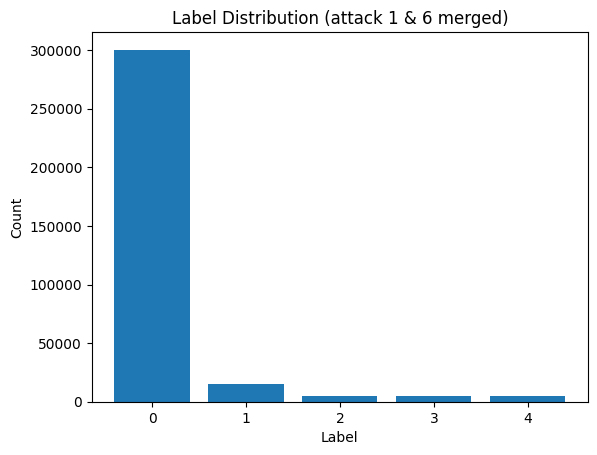

label
0    300332
1     15000
2      5000
3      5000
4      5000
Name: count, dtype: int64

Mapping:
BENIGN -> 0
DrDoS_DNS -> 1
DrDoS_LDAP -> 1
DrDoS_MSSQL -> 2
DrDoS_NetBIOS -> 3
DrDoS_NTP -> 4
DrDoS_SNMP -> 1
Mapping saved to 'goofy_label_mapping.json'
Model Index BENIGN -> 0
Model Index DrDoS_DNS -> 1
Model Index DrDoS_LDAP -> 1
Model Index DrDoS_MSSQL -> 2
Model Index DrDoS_NetBIOS -> 3
Model Index DrDoS_NTP -> 4
Model Index DrDoS_SNMP -> 1


In [14]:
import matplotlib.pyplot as plt
import json
if 0:# use this if the classes arent retarded
    df3 = df.copy()

    # create mapping: BENIGN -> 0, each DDoS gets a unique integer
    label_map = {'BENIGN': 0}

    for i, ddos_name in enumerate(attack_columns, start=1):
        label_map[ddos_name] = i

    # apply mapping
    df3['label'] = df3['label'].map(label_map)

    # visualize
    counts = df3['label'].value_counts().sort_index()
    with open('drdos_label_mapping.json', 'w') as f:
        json.dump(label_map, f, indent=4)
    plt.bar(counts.index, counts.values)
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.title("Label Distribution")
    plt.show()

    print(counts)
if 1:
    import matplotlib.pyplot as plt
    import json

    df3 = df.copy()

    # base mapping
    label_map = {'BENIGN': 0}

    # attacks list (original order)
    # attack_columns = [attack1, attack2, attack3, attack4, attack5, attack6, ...]
    merged_attacks = {
        attack_columns[0],  # attack 1
        attack_columns[1],  # attack 2
        attack_columns[5],  # attack 6
    }

    new_idx = 1
    for name in attack_columns:
        if name in merged_attacks:
            label_map[name] = 1   # merged class
        else:
            new_idx += 1
            label_map[name] = new_idx

    # apply mapping
    df3['label'] = df3['label'].map(label_map)

    # visualize distribution
    counts = df3['label'].value_counts().sort_index()

    with open('drdos_label_mapping.json', 'w') as f:
        json.dump(label_map, f, indent=4)

    plt.bar(counts.index, counts.values)
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.title("Label Distribution (attack 1 & 6 merged)")
    plt.show()

    print(counts)

    print("\nMapping:")
    for k, v in label_map.items():
        print(f"{k} -> {v}")



# -------------------------
# 7. Print mapping nicely
# -------------------------




print("Mapping saved to 'goofy_label_mapping.json'")
for k, v in label_map.items():
    print(f"Model Index {k} -> {v}")


In [15]:
from sklearn.preprocessing import MinMaxScaler

# Replace inf/-inf with NaN and drop them
df3.replace([np.inf, -np.inf], np.nan, inplace=True)
df3.dropna(inplace=True)

# Choose the columns to scale (exclude "label")
cols_to_scale = [col for col in df3.columns if col != "label"]

# Initialize one scaler for all numeric columns
scaler = MinMaxScaler()

# Fit and transform only the selected columns
df3[cols_to_scale] = scaler.fit_transform(df3[cols_to_scale])

# Recombine if needed
df3 = df3[best_feat]
print(df3)


        bidirectional_bytes  src2dst_bytes  bidirectional_min_ps  \
85350          4.565522e-06   1.018526e-04              1.000000   
85351          4.565522e-06   1.018526e-04              1.000000   
85352          4.491686e-06   1.002054e-04              0.983494   
85353          4.565522e-06   1.018526e-04              1.000000   
85354          4.491686e-06   1.002054e-04              0.983494   
...                     ...            ...                   ...   
501415         5.230046e-07   7.137917e-06              0.004127   
501416         1.107539e-07   2.059015e-07              0.004127   
501417         1.107539e-07   2.059015e-07              0.004127   
501418         1.107539e-07   2.059015e-07              0.004127   
501419         1.015244e-07   0.000000e+00              0.000000   

        bidirectional_mean_ps  bidirectional_max_ps  src2dst_min_ps  \
85350                0.684880              0.058596        1.000000   
85351                0.684880            

In [16]:
print(df3['label'].unique())

[1 2 3 4 0]


In [17]:
import joblib
joblib.dump(scaler, 'minmax_scaler_drdos_attack_nfstream.pkl')

['minmax_scaler_drdos_attack_nfstream.pkl']

# hyperparamter search with grid search and smote using xgb boost

Downsampled shape: (45000, 14)
label
0    15000
1    15000
4     5000
2     5000
3     5000
Name: count, dtype: int64
After SMOTE:
label
0    15000
4    14995
1    14931
3    14912
2    14886
Name: count, dtype: int64
Number of classes: 5
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Validation Macro F1: 0.9693

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       0.94      0.98      0.96      2986
           2       0.92      0.94      0.93      2977
           3       0.99      0.93      0.96      2983
           4       1.00      1.00      1.00      2999

    accuracy                           0.97     14945
   macro avg       0.97      0.97      0.97     14945
weighted avg       0.97      0.97      0.97     14945



<Figure size 1200x1200 with 0 Axes>

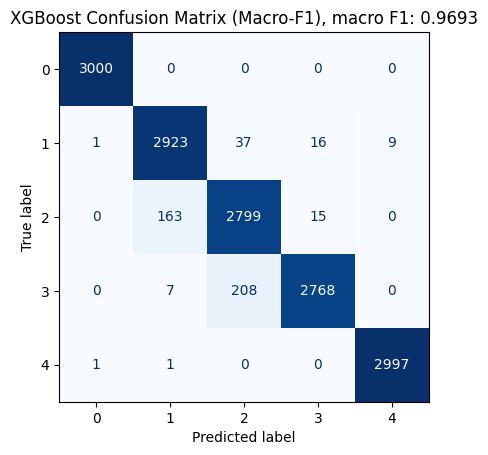

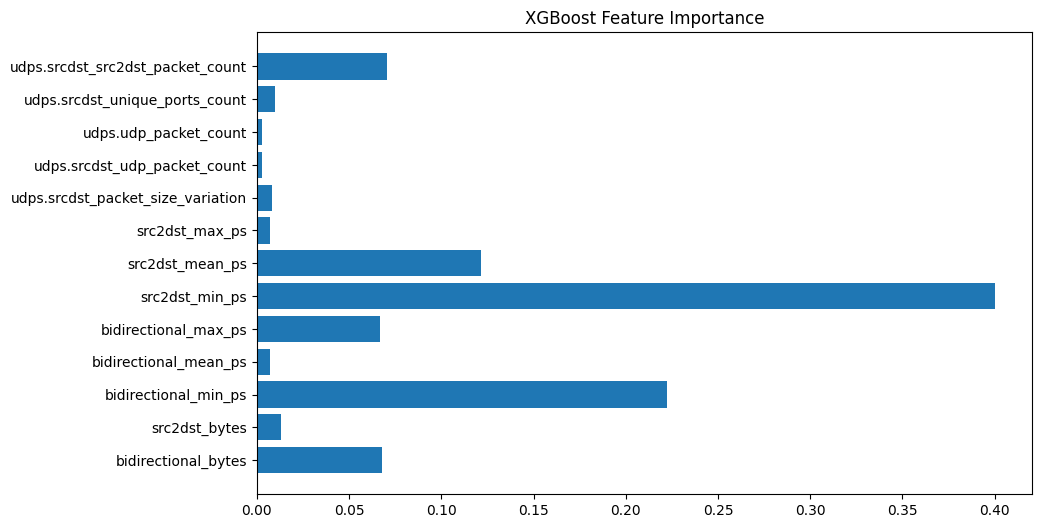

best {'subsample': 0.8, 'n_estimators': 700, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [18]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.utils import resample
import joblib

# =========================
# 1. Downsampling
# =========================
df_benign = df3[df3['label'] == 0]
df_attack = df3[df3['label'] > 0]

df_benign_downsampled = resample(
    df_benign,
    replace=False,
    n_samples=int(len(df_attack)*0.5) ,
    random_state=42
)

df_downsampled = pd.concat([df_benign_downsampled, df_attack])
df_downsampled = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Downsampled shape: {df_downsampled.shape}")
print(df_downsampled['label'].value_counts())

# =========================
# 2. Features / Labels
# =========================
cols = [c for c in best_feat if c.lower() != 'label']

X = df_downsampled[cols]
y = df_downsampled['label']

from imblearn.combine import SMOTETomek

adasyn = SMOTETomek(sampling_strategy='not majority')
X_res, y_res = adasyn.fit_resample(X, y)
print("After SMOTE:")
print(y_res.value_counts())
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res,
    test_size=0.2,
    stratify=y_res,
    random_state=42
)

num_classes = y_train.nunique()
print("Number of classes:", num_classes)
# =========================
# 3. Train XGBoost
# =========================
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train # provide your target variable
)
model = XGBClassifier(
  tree_method="hist",
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    
    
    random_state=42
)
param_grid = {
    'n_estimators': [ 300,500,700,900],
    'max_depth': [ 5,7,9],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],

}


from sklearn.model_selection import RandomizedSearchCV
grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=5, cv=5, n_jobs=-1, verbose=3)
# This reduces 4,725 fits to 250 fits (~2 hours)
grid_search.fit(X_train, y_train)

# =========================
# 4. Evaluation (MACRO F1 ONLY)
# =========================
val_pred = grid_search.predict(X_val)

val_macro_f1 = f1_score(y_val, val_pred, average='macro')
print(f"\nValidation Macro F1: {val_macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, val_pred))

# =========================
# 5. Confusion Matrix
# =========================
plt.figure(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_pred,
    cmap='Blues',
    display_labels=grid_search.best_estimator_.classes_,
    colorbar=False
)
plt.title('XGBoost Confusion Matrix (Macro-F1), macro F1: {:.4f}'.format(val_macro_f1))
plt.grid(False)
plt.show()

# =========================
# 6. Feature Importance
# =========================
plt.figure(figsize=(10, 6))
plt.barh(X.columns, grid_search.best_estimator_.feature_importances_)
plt.title('XGBoost Feature Importance')
plt.show()

# =========================
# 7. Save Artifacts
# =========================
joblib.dump(grid_search.best_estimator_, 'xgboost_drdos_model_nfstream.pkl')
joblib.dump(best_feat, 'xgboost_drdos_features_nfstream.pkl')
print("best", grid_search.best_params_)




In [ ]:
with open('ddos_label_mapping.json', 'w') as f:
    json.dump(goofy_mapping_readable, f, indent=4)

NameError: name 'goofy_mapping_readable' is not defined

In [ ]:
import joblib

scaler = joblib.load(r"descion_tree__ddos_scaler_nfstream.pkl")

print("n_features_in_:", scaler.n_features_in_)
print("Feature names:", getattr(scaler, "feature_names_in_", None))


n_features_in_: 88
Feature names: ['bidirectional_duration_ms' 'bidirectional_packets' 'bidirectional_bytes'
 'src2dst_duration_ms' 'src2dst_packets' 'src2dst_bytes'
 'dst2src_duration_ms' 'dst2src_packets' 'dst2src_bytes'
 'bidirectional_min_ps' 'bidirectional_mean_ps' 'bidirectional_stddev_ps'
 'bidirectional_max_ps' 'src2dst_min_ps' 'src2dst_mean_ps'
 'src2dst_stddev_ps' 'src2dst_max_ps' 'dst2src_min_ps' 'dst2src_mean_ps'
 'dst2src_stddev_ps' 'dst2src_max_ps' 'bidirectional_min_piat_ms'
 'bidirectional_mean_piat_ms' 'bidirectional_stddev_piat_ms'
 'bidirectional_max_piat_ms' 'src2dst_min_piat_ms' 'src2dst_mean_piat_ms'
 'src2dst_stddev_piat_ms' 'src2dst_max_piat_ms' 'dst2src_min_piat_ms'
 'dst2src_mean_piat_ms' 'dst2src_stddev_piat_ms' 'dst2src_max_piat_ms'
 'bidirectional_syn_packets' 'bidirectional_cwr_packets'
 'bidirectional_ece_packets' 'bidirectional_urg_packets'
 'bidirectional_ack_packets' 'bidirectional_psh_packets'
 'bidirectional_rst_packets' 'bidirectional_fin_packets'
 

In [ ]:
print(cols)

['bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'bidirectional_stddev_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms', 'udps.srcdst_packet_size_variation', 'udps.srcdst_tcp_packet_count', 'udps.tcp_packet_count', 'udps.src2dst_packet_count', 'udps.bidirectional_packet_count', 'udps.srcdst_src2dst_packet_count', 'udps.srcdst_bidirectional_packet_count']


In [ ]:
best_feat.remove('label')
joblib.dump(best_feat, 'decision_tree_ddos_features_nfstream.pkl')

['decision_tree_ddos_features_nfstream.pkl']